In [1]:
# Importing required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Setting plot style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Loading the dataset
df = pd.read_csv(r'E:\Data_analyst_journey\Complete_Project\Sample - Superstore.csv', encoding='latin-1')

# First look at data
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
print("Rows & Columns:", df.shape)

Rows & Columns: (9994, 21)


In [4]:
print("Missing Values:\n", df.isnull().sum())

Missing Values:
 Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [5]:
print("\nDuplicate Rows:", df.duplicated().sum())



Duplicate Rows: 0


In [6]:
# Remove duplicates
df.drop_duplicates(inplace=True)

# Convert date columns
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Extract month and year
df['Month'] = df['Order Date'].dt.month
df['Year'] = df['Order Date'].dt.year

print("Data cleaned successfully!")

Data cleaned successfully!


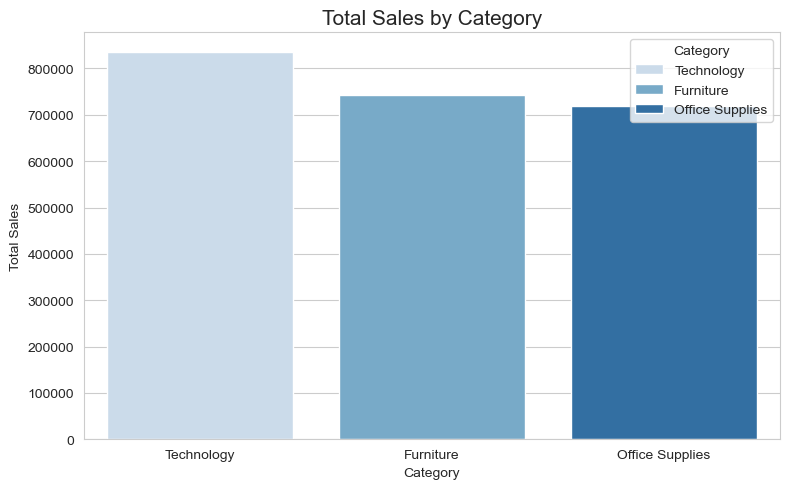

In [9]:
# Sales by Category
category_sales = df.groupby('Category')['Sales'].sum().reset_index()
category_sales = category_sales.sort_values('Sales', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x='Category', y='Sales', data=category_sales, 
            hue='Category', palette='Blues', legend=True)
plt.title('Total Sales by Category', fontsize=15)
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()

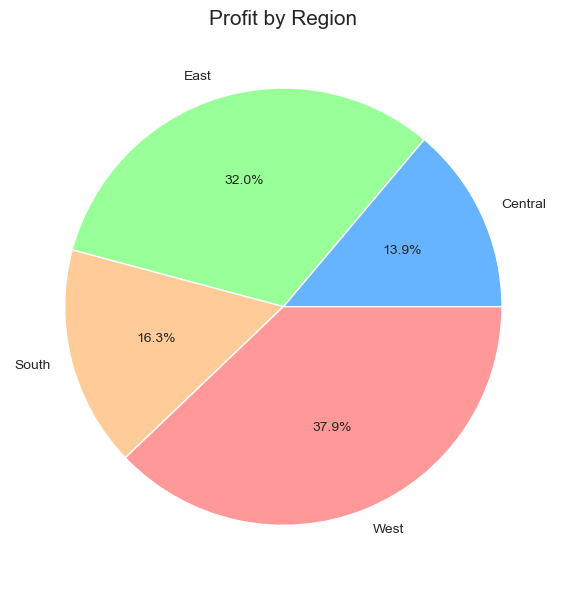

In [10]:
# Profit by Region
region_profit = df.groupby('Region')['Profit'].sum()

plt.figure(figsize=(8, 6))
region_profit.plot(kind='pie', autopct='%1.1f%%', 
                   colors=['#66b3ff','#99ff99','#ffcc99','#ff9999'])
plt.title('Profit by Region', fontsize=15)
plt.ylabel('')
plt.tight_layout()
plt.show()

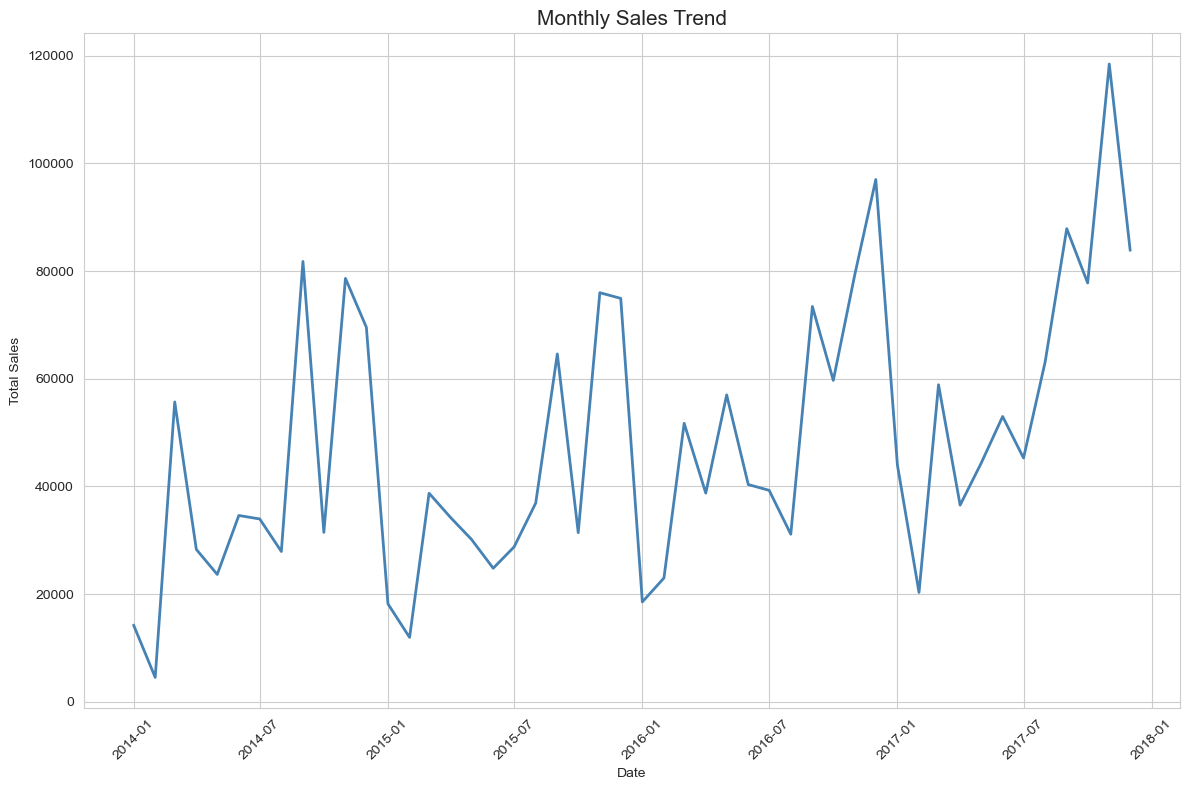

In [12]:
# Monthly Sales Trend
monthly_sales = df.groupby(['Year', 'Month'])['Sales'].sum().reset_index()
monthly_sales['Date'] = pd.to_datetime(monthly_sales[['Year', 'Month']].assign(Day=1))

plt.figure(figsize=(12, 8))
sns.lineplot(x='Date', y='Sales', data=monthly_sales, color='steelblue', linewidth=2)
plt.title('Monthly Sales Trend', fontsize=15)
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

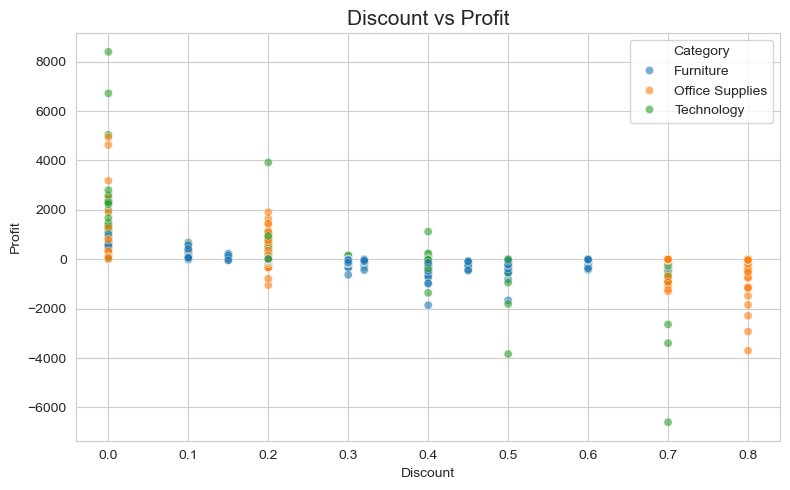

In [13]:
# Discount vs Profit
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Discount', y='Profit', data=df, 
                hue='Category', alpha=0.6)
plt.title('Discount vs Profit', fontsize=15)
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.tight_layout()
plt.show()

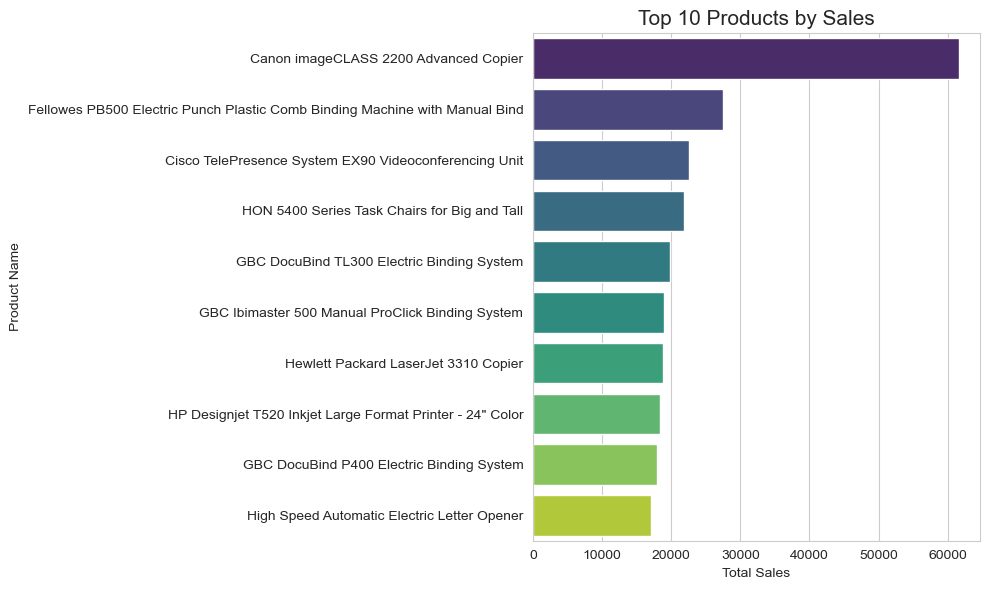

In [18]:
# Top 10 Products
top10 = df.groupby('Product Name')['Sales'].sum().nlargest(10).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='Sales', y='Product Name', data=top10, 
            hue='Product Name', palette='viridis', legend=False)
plt.title('Top 10 Products by Sales', fontsize=15)
plt.xlabel('Total Sales')
plt.ylabel('Product Name')
plt.tight_layout()
plt.show()

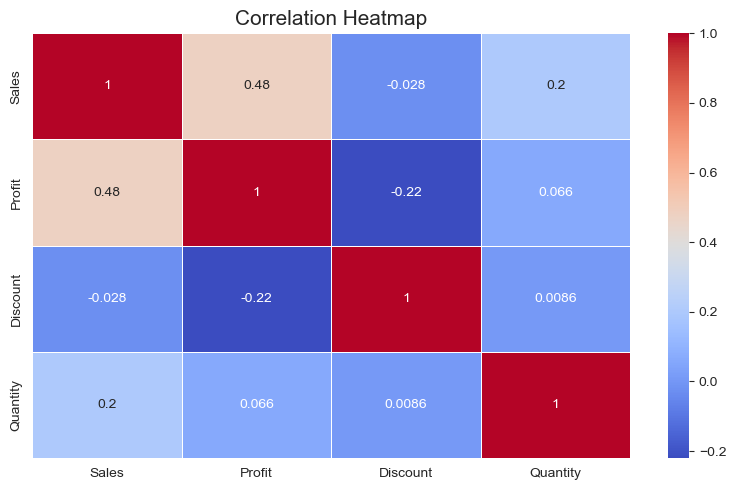

In [15]:
# Correlation Heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(df[['Sales', 'Profit', 'Discount', 'Quantity']].corr(), 
            annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=15)
plt.tight_layout()
plt.show()

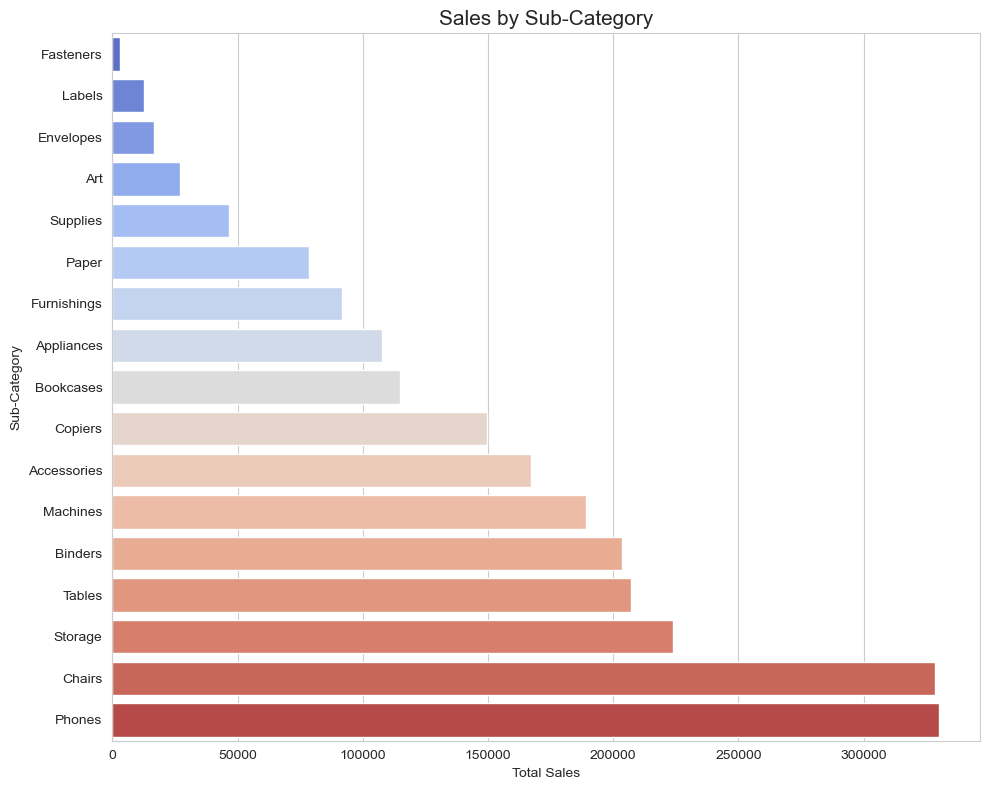

In [17]:
# Sales by Sub-Category
sub_cat = df.groupby('Sub-Category')['Sales'].sum().reset_index()
sub_cat = sub_cat.sort_values('Sales', ascending=True)

plt.figure(figsize=(10, 8))
sns.barplot(x='Sales', y='Sub-Category', data=sub_cat, 
            hue='Sub-Category', palette='coolwarm', legend=False)
plt.title('Sales by Sub-Category', fontsize=15)
plt.xlabel('Total Sales')
plt.ylabel('Sub-Category')
plt.tight_layout()
plt.show()